# Hackathon 5 - Model Showdown

## Credit Card Default Prediction

This notebook compares three classification models - KNN, Logistic Regression and Random Forest - for predicting whether a customer will default on a credit-card payment.

The project is connected to **SDG 8: Decent Work and Economic Growth** because financial security and access to financial services are connected to economic security.

Our main evaluation metric is **recall**, because missing an actual defaulter (a false negative) is an important error for this prediction problem.

The goal is not only to build a model, but to compare the models honestly, understand their limitations, and recommend an appropriate model for decision support.


# 1. Dataset Loading

We load the UCI Credit Card Default dataset directly from its source and display the first rows to understand the data structure.

In [1]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"

df = pd.read_excel(url, header=1)

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### Dataset Size

We check the number of rows and columns in the dataset.

In [2]:
df.shape

(30000, 25)

### Missing Values Check

We check every column for missing values to make sure the dataset is complete.

In [3]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


### Duplicate Rows Check

We check whether the dataset contains duplicate rows.

In [4]:
df.duplicated().sum()

np.int64(0)

### Target Distribution

We check how many customers defaulted and how many did not. This helps us understand the class balance.

In [5]:
df["default payment next month"].value_counts()

,count
default payment next month,
0,23364
1,6636


### Data Types

We inspect the data type of each column before preprocessing.

In [6]:
df.dtypes

,0
ID,int64
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


### Descriptive Statistics

We look at basic statistics such as the mean, minimum, maximum and quartiles of the numerical variables.

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Education Values

We inspect the different education categories and how often each category appears.

In [8]:
df["EDUCATION"].value_counts().sort_index()

,count
EDUCATION,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


### Marriage Values

We inspect the different marriage categories and their frequencies.

In [9]:
df["MARRIAGE"].value_counts().sort_index()

,count
MARRIAGE,
0,54
1,13659
2,15964
3,323


### Repayment Status Values

We inspect the values in PAY_0 to understand the repayment-status categories in the dataset.

In [10]:
df["PAY_0"].value_counts().sort_index()


,count
PAY_0,
-2,2759
-1,5686
0,14737
1,3688
2,2667
3,322
4,76
5,26
6,11


### Unique Customer IDs

We check the number of unique IDs to make sure each customer has a unique identifier.

In [11]:
df["ID"].nunique()

30000

### Default by Sex

We compare default counts across the two sex groups.

In [12]:
pd.crosstab(df["SEX"], df["default payment next month"])

default payment next month,0,1
SEX,,
1,9015,2873
2,14349,3763


### Default by Education

We compare default counts across education categories.

In [13]:
pd.crosstab(df["EDUCATION"], df["default payment next month"])

default payment next month,0,1
EDUCATION,,
0,14,0
1,8549,2036
2,10700,3330
3,3680,1237
4,116,7
5,262,18
6,43,8


### Default Rate by Education

We calculate the percentage of customers who default within each education category.

In [14]:
df.groupby("EDUCATION")["default payment next month"].mean() * 100

,default payment next month
EDUCATION,
0,0.000000
1,19.234766
2,23.734854
3,25.157616
4,5.691057
5,6.428571
6,15.686275


### Credit Limit and Default

We compare the average credit limit for customers who defaulted and customers who did not.

In [15]:
df.groupby("default payment next month")["LIMIT_BAL"].mean()

,LIMIT_BAL
default payment next month,
0,178099.726074
1,130109.656420


### Key Numerical Features

We inspect the distributions of credit limit, age, bill amount and payment amount.

In [16]:
df[["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]].describe()

,LIMIT_BAL,AGE,BILL_AMT1,PAY_AMT1
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,35.485500,51223.330900,5663.580500
std,129747.661567,9.217904,73635.860576,16563.280354
min,10000.000000,21.000000,-165580.000000,0.000000
25%,50000.000000,28.000000,3558.750000,1000.000000
50%,140000.000000,34.000000,22381.500000,2100.000000
75%,240000.000000,41.000000,67091.000000,5006.000000
max,1000000.000000,79.000000,964511.000000,873552.000000


# 2. Define Features and Target

We separate the target variable from the input features and remove the ID because it is an identifier, not a useful predictive feature.

In [17]:
X = df.drop(columns=["default payment next month", "ID"])
y = df["default payment next month"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (30000, 23)
Target: (30000,)


# 3. Train/Test Split

We split the data into 80% training data and 20% test data. Stratification keeps the target-class proportions similar in both sets.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (24000, 23)
Test data: (6000, 23)


# 4. Import the Machine-Learning Models

We import the preprocessing tools and the three classifiers used in the Model Showdown: KNN, Logistic Regression and Random Forest.

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 5. Baseline Model

We create a simple baseline that always predicts the most frequent class. This gives us a reference point for judging whether the machine-learning models add value.

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score

baseline = DummyClassifier(strategy="most_frequent")

# Fit the baseline on the training data.
# Final test-set evaluation is done later in the final comparison section.
baseline.fit(X_train, y_train)

baseline_train_pred = baseline.predict(X_train)
baseline_train_recall = recall_score(y_train, baseline_train_pred)

print("Baseline training recall:", baseline_train_recall)


Baseline training recall: 0.0


# 6. Preprocessing Pipeline

We define which variables are categorical and numerical. Numerical variables are standardized, while categorical variables are one-hot encoded. The preprocessing is kept inside the pipeline to avoid data leakage.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "SEX", "EDUCATION", "MARRIAGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"
]

numerical_features = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


# 7. KNN Model

We create the K-Nearest Neighbors pipeline using the shared preprocessing step.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

print("KNN pipeline created successfully!")

KNN pipeline created successfully!


# 8. Logistic Regression Model

We create the Logistic Regression pipeline using the same preprocessing as KNN.

In [23]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


# 9. Random Forest Model

We create the Random Forest pipeline using the same preprocessing approach.

In [24]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


# 10. Hyperparameter Tuning - KNN

We use 5-fold cross-validation to test different KNN settings and select the configuration with the highest recall.

In [25]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    "model__n_neighbors": [3, 5, 7, 11, 15],
    "model__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best KNN parameters:", knn_grid.best_params_)
print("Best KNN CV Recall:", knn_grid.best_score_)

Best KNN parameters: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Best KNN CV Recall: 0.3552433389954756


# 11. Hyperparameter Tuning - Logistic Regression

We test different values of C using 5-fold cross-validation and select the value that gives the best recall.

In [26]:
logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:", logistic_grid.best_params_)
print("Best Logistic Regression CV Recall:", logistic_grid.best_score_)

Best Logistic Regression parameters: {'model__C': 10}
Best Logistic Regression CV Recall: 0.36033252217376566


# 12. Hyperparameter Tuning - Random Forest

We test different Random Forest settings using 5-fold cross-validation and select the configuration with the best recall.

In [27]:
random_forest_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

random_forest_grid = GridSearchCV(
    random_forest_pipeline,
    random_forest_params,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

print("Best Random Forest parameters:", random_forest_grid.best_params_)
print("Best Random Forest CV Recall:", random_forest_grid.best_score_)

Best Random Forest parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best Random Forest CV Recall: 0.3731397910154759


# Hyperparameter Tuning Results

We visualize how the KNN hyperparameter `n_neighbors` affects cross-validation recall.

This helps us understand why the selected KNN configuration was chosen.

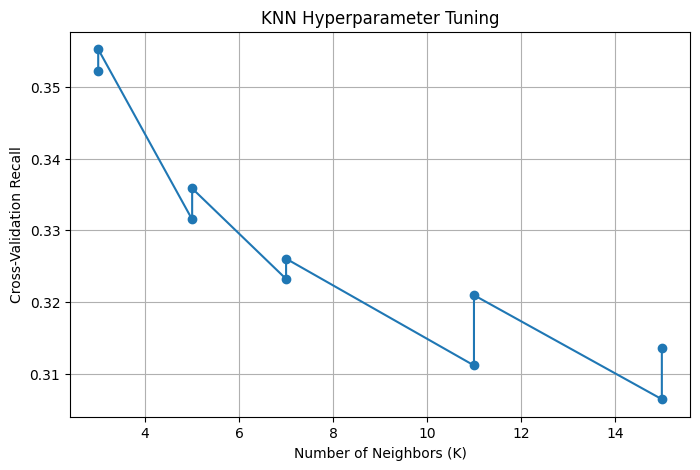

In [28]:
import matplotlib.pyplot as plt

knn_results = pd.DataFrame(knn_grid.cv_results_)

plt.figure(figsize=(8, 5))

plt.plot(
    knn_results["param_model__n_neighbors"],
    knn_results["mean_test_score"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validation Recall")
plt.title("KNN Hyperparameter Tuning")
plt.grid(True)
plt.show()

# 13. Prepare the Tuned Models

We collect the best tuned version of each model so that we can evaluate and compare them consistently.

In [29]:
models = {
    "KNN": knn_grid.best_estimator_,
    "Logistic Regression": logistic_grid.best_estimator_,
    "Random Forest": random_forest_grid.best_estimator_
}

print("Models restored successfully!")

Models restored successfully!


# 14. Confusion Matrices - Numerical Results

We calculate the confusion matrix for each tuned model to see correct and incorrect predictions.

In [30]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(name)
    print(cm)
    print()

KNN
[[4151  522]
 [ 848  479]]

Logistic Regression
[[4433  240]
 [ 859  468]]

Random Forest
[[4417  256]
 [ 846  481]]



# 15. Confusion Matrices - Visual Results

We visualize the confusion matrices so that the types of prediction errors are easier to interpret.

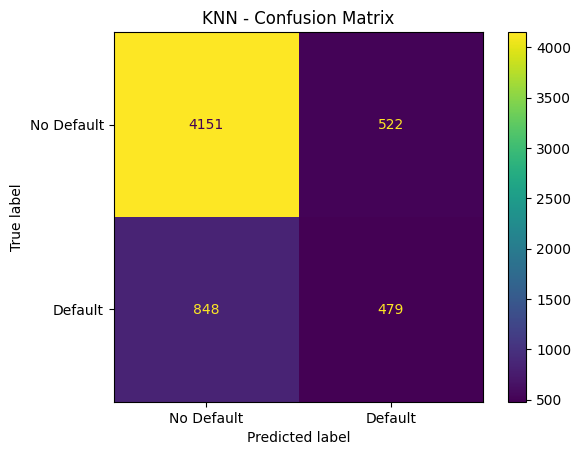

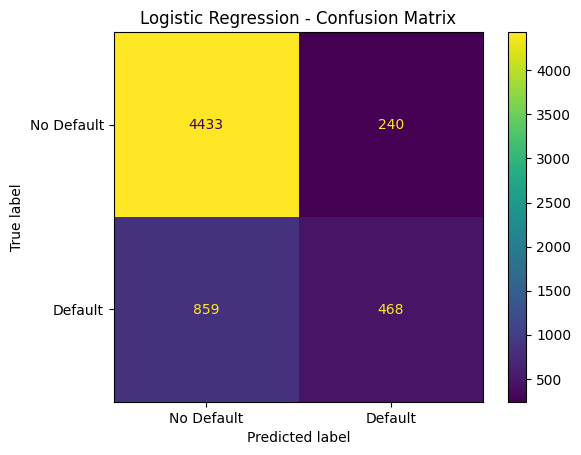

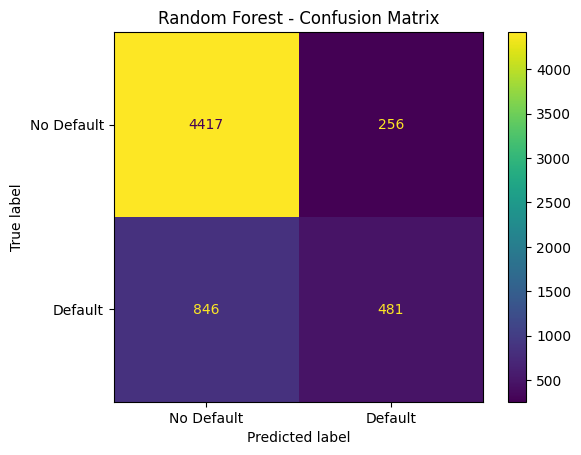

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Default", "Default"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

# 16. Error Analysis - False Negatives

We focus on false negatives: customers who actually defaulted but were predicted as non-defaulters. This is especially important because recall is our main metric.

In [32]:
rf_pred = random_forest_grid.best_estimator_.predict(X_test)

false_negatives = X_test[(y_test == 1) & (rf_pred == 0)]

print("Number of false negatives:", len(false_negatives))
false_negatives.describe()

Number of false negatives: 846


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,...,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,152420.425532,1.574468,1.894799,1.505910,36.278960,-0.070922,-0.135934,-0.200946,-0.273050,-0.296690,...,41064.991726,36907.877069,34154.369976,33080.118203,3664.648936,3849.846336,3408.218676,2998.212766,3142.921986,3530.458629
std,124001.879760,0.494716,0.745509,0.523383,9.477483,1.139783,1.335615,1.322468,1.316228,1.272621,...,75619.286261,66504.854597,61864.622787,61025.583380,8717.284991,13777.060959,10188.079253,9147.237694,9061.243217,11430.707717
min,10000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-46127.000000,-65167.000000,-53007.000000,-94625.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,591.500000,495.000000,390.000000,318.250000,0.000000,23.500000,0.000000,0.000000,0.000000,0.000000
50%,120000.000000,2.000000,2.000000,1.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10312.000000,10695.000000,9940.000000,7779.000000,1501.500000,1500.000000,1105.000000,834.500000,1000.000000,1000.000000
75%,230000.000000,2.000000,2.000000,2.000000,43.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,46649.250000,39902.750000,35050.000000,34473.750000,3600.000000,3515.000000,3000.000000,2763.500000,3000.000000,3000.000000
max,550000.000000,2.000000,6.000000,3.000000,70.000000,8.000000,7.000000,7.000000,7.000000,7.000000,...,578971.000000,493548.000000,429966.000000,427216.000000,125000.000000,302000.000000,179460.000000,128000.000000,107591.000000,196000.000000


### False Negatives vs. True Positives

We compare the average characteristics of customers missed by Random Forest with customers who were correctly identified as defaulters.

In [33]:
true_positives = X_test[(y_test == 1) & (rf_pred == 1)]

comparison = pd.DataFrame({
    "False Negatives": false_negatives.mean(),
    "True Positives": true_positives.mean()
})

comparison

,False Negatives,True Positives
LIMIT_BAL,152420.425532,111476.091476
SEX,1.574468,1.582121
EDUCATION,1.894799,1.916840
MARRIAGE,1.505910,1.505198
AGE,36.278960,35.544699
PAY_0,-0.070922,1.877339
PAY_2,-0.135934,1.449064
PAY_3,-0.200946,1.282744
PAY_4,-0.273050,1.139293
PAY_5,-0.296690,1.085239


# 17. Subgroup Analysis

We compare Random Forest recall between the two sex groups to check whether performance is noticeably different across these groups.

In [34]:
for sex in sorted(X_test["SEX"].unique()):
    mask = X_test["SEX"] == sex
    print(
        "SEX", sex,
        "- Recall:",
        recall_score(y_test[mask], rf_pred[mask])
    )

SEX 1 - Recall: 0.3582887700534759
SEX 2 - Recall: 0.36553524804177545


# 18. New Customer Prediction

We create a fictional customer and use the tuned Random Forest model to predict whether the customer is likely to default and to calculate the predicted probabilities.

In [35]:
new_customer = pd.DataFrame([{
    "LIMIT_BAL": 50000,
    "SEX": 2,
    "EDUCATION": 2,
    "MARRIAGE": 2,
    "AGE": 30,
    "PAY_0": 2,
    "PAY_2": 2,
    "PAY_3": 1,
    "PAY_4": 0,
    "PAY_5": 0,
    "PAY_6": 0,
    "BILL_AMT1": 40000,
    "BILL_AMT2": 38000,
    "BILL_AMT3": 35000,
    "BILL_AMT4": 30000,
    "BILL_AMT5": 28000,
    "BILL_AMT6": 25000,
    "PAY_AMT1": 1000,
    "PAY_AMT2": 1000,
    "PAY_AMT3": 1500,
    "PAY_AMT4": 1500,
    "PAY_AMT5": 2000,
    "PAY_AMT6": 2000
}])

prediction = random_forest_grid.best_estimator_.predict(new_customer)
probability = random_forest_grid.best_estimator_.predict_proba(new_customer)

print("Prediction:", prediction[0])
print("Probability of No Default:", probability[0][0])
print("Probability of Default:", probability[0][1])

Prediction: 1
Probability of No Default: 0.466920634920635
Probability of Default: 0.5330793650793649


## Final Model Recommendation

Random Forest was selected as our preferred model because recall was our primary evaluation metric. In credit-card default prediction, identifying as many actual defaulters as possible is important.

On the test set, Random Forest achieved:
- Accuracy: 81.63%
- Precision: 65.26%
- Recall: 36.25%
- F1-score: 46.61%

Random Forest achieved the highest recall and F1-score among the three tested models. However, Logistic Regression achieved slightly higher accuracy and precision. Therefore, the choice of Random Forest reflects our priority of identifying potential defaulters rather than maximizing overall accuracy.

The model should be used as a decision-support tool rather than as an automatic decision-maker.

# 19. Model Comparison

We create a table comparing KNN, Logistic Regression and Random Forest using accuracy, precision, recall and F1-score.

In [36]:
results_df = pd.DataFrame([
    {
        "Model": "KNN",
        "Accuracy": 0.771667,
        "Precision": 0.478521,
        "Recall": 0.360965,
        "F1": 0.411512
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.816833,
        "Precision": 0.661017,
        "Recall": 0.352675,
        "F1": 0.459951
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.816333,
        "Precision": 0.652646,
        "Recall": 0.362472,
        "F1": 0.466085
    }
])

results_df

,Model,Accuracy,Precision,Recall,F1
0,KNN,0.771667,0.478521,0.360965,0.411512
1,Logistic Regression,0.816833,0.661017,0.352675,0.459951
2,Random Forest,0.816333,0.652646,0.362472,0.466085


### Model Performance Visualization

We visualize the main evaluation metrics for the three models so their performance can be compared easily.

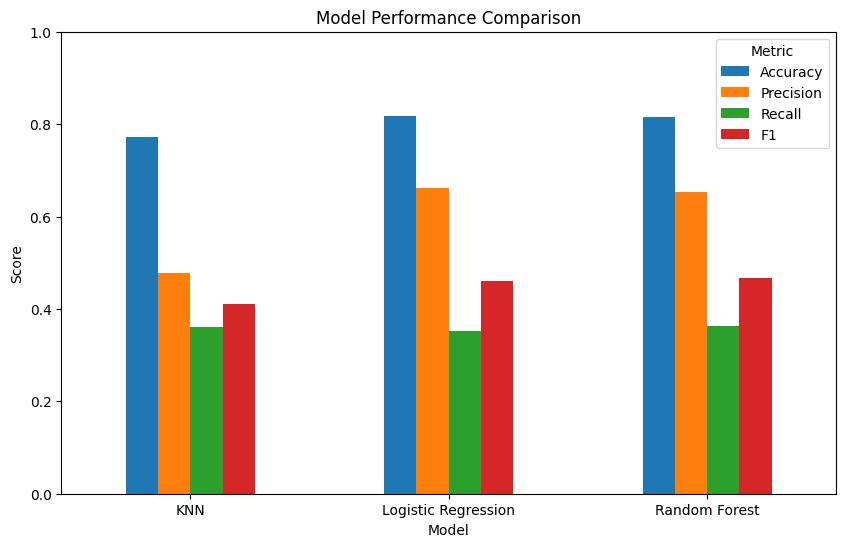

In [37]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

## Ethical Reflection

Our model predicts whether a customer may default on their credit-card payment. This can affect people's financial opportunities, so an incorrect prediction can have real consequences.

### Fairness and bias

The dataset contains demographic variables such as sex, education and marriage. These variables can create fairness concerns if the model performs differently for different groups. We therefore checked recall for the two sex groups.

Random Forest achieved 35.83% recall for SEX 1 and 36.55% for SEX 2. The difference was small, but this single check is not enough to prove that the model is completely fair. More groups and more fairness measures would be needed before real-world use.

### False negatives

Our main metric was recall because missing an actual defaulter can be an important error in a credit-risk context. However, the final Random Forest model still produced 846 false negatives. This means that many customers who actually defaulted were predicted as non-defaulters.

Our error analysis showed that the false negatives generally had less obvious repayment-delay patterns than the customers who were correctly identified as defaulters. This shows an important limitation of the model.

### Transparency and accountability

A credit prediction should not automatically determine whether someone receives or loses access to financial services. Our Random Forest model should therefore be treated as a decision-support tool, not as an automatic decision-maker.

A person affected by such a decision should have human oversight and the possibility to question or challenge the decision.

### Data limitations and privacy

The dataset represents a specific population and period, so its results may not generalise to other countries, populations or time periods. We should not assume that the model will perform equally well for people who are not represented in the original data.

The dataset also contains personal and demographic information. Any real-world use would therefore require careful attention to privacy, data protection, consent and the permitted use of the data.

### Overall

The model can support the identification of potential credit-card default risk, but it should not be treated as a perfect or neutral decision-maker. Our evaluation shows that Random Forest performs best on recall and F1 among the tested models, but it still misses many actual defaulters. Further testing for fairness, transparency and performance on different populations would be necessary before real-world deployment.

# 20. Final Comparison Table

We create the final comparison table required for the Hackathon.

The table includes the baseline, best hyperparameters, training recall, cross-validation recall with its spread, and final test-set metrics.

The test set is used only here and in the final error and subgroup analysis after the tuned models have been selected using training data and cross-validation.

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Baseline
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

# Function to get training and test results
def get_model_results(model):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "Training Recall": recall_score(y_train, train_pred),
        "Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred, zero_division=0),
        "Recall": recall_score(y_test, test_pred),
        "F1": f1_score(y_test, test_pred)
    }

# Get CV results from the already-fitted GridSearchCV objects
def get_cv_info(grid):
    best_index = grid.best_index_
    return (
        grid.best_score_,
        grid.cv_results_["std_test_score"][best_index],
        grid.best_params_
    )

knn_cv, knn_std, knn_params = get_cv_info(knn_grid)
log_cv, log_std, log_params = get_cv_info(logistic_grid)
rf_cv, rf_std, rf_params = get_cv_info(random_forest_grid)

# Create final comparison table
final_results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Best Parameters": "Most frequent class",
        "CV Recall": "-",
        "Training Recall": recall_score(y_train, baseline.predict(X_train)),
        "Accuracy": accuracy_score(y_test, baseline_pred),
        "Precision": precision_score(y_test, baseline_pred, zero_division=0),
        "Recall": recall_score(y_test, baseline_pred),
        "F1": f1_score(y_test, baseline_pred)
    },
    {
        "Model": "KNN",
        "Best Parameters": str(knn_params),
        "CV Recall": f"{knn_cv:.3f} ± {knn_std:.3f}",
        **get_model_results(knn_grid.best_estimator_)
    },
    {
        "Model": "Logistic Regression",
        "Best Parameters": str(log_params),
        "CV Recall": f"{log_cv:.3f} ± {log_std:.3f}",
        **get_model_results(logistic_grid.best_estimator_)
    },
    {
        "Model": "Random Forest",
        "Best Parameters": str(rf_params),
        "CV Recall": f"{rf_cv:.3f} ± {rf_std:.3f}",
        **get_model_results(random_forest_grid.best_estimator_)
    }
])

final_results


,Model,Best Parameters,CV Recall,Training Recall,Accuracy,Precision,Recall,F1
0,Baseline,Most frequent class,-,0.00000,0.778833,0.000000,0.000000,0.000000
1,KNN,"{'model__n_neighbors': 3, 'model__weights': 'd...",0.355 ± 0.009,0.99774,0.771667,0.478521,0.360965,0.411512
2,Logistic Regression,{'model__C': 10},0.360 ± 0.012,0.36391,0.816833,0.661017,0.352675,0.459951
3,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.373 ± 0.009,0.89207,0.816333,0.652646,0.362472,0.466085


### Training, Cross-Validation, and Test Recall

The training recall shows how well each tuned model identifies default cases in the training data. The cross-validation recall shows performance across different training folds, while the final test recall shows performance on the unseen test set.

The gaps between these scores help us check whether a model may be overfitting. A much higher training score than cross-validation and test performance would suggest that the model fits the training data better than it generalizes to unseen data.

For this project, the final recommendation is based mainly on cross-validation recall and the final test results, while the test set is kept separate from model selection.

### Clean Final Comparison

We shorten the hyperparameter descriptions so the final comparison table is easier to read.

In [39]:
clean_results = final_results.copy()

clean_results["Best Parameters"] = [
    "Most frequent class",
    "n_neighbors=3, weights=distance",
    "C=10",
    "n_estimators=100, max_depth=None, min_samples_split=5"
]

clean_results.round(3)

,Model,Best Parameters,CV Recall,Training Recall,Accuracy,Precision,Recall,F1
0,Baseline,Most frequent class,-,0.000,0.779,0.000,0.000,0.000
1,KNN,"n_neighbors=3, weights=distance",0.355 ± 0.009,0.998,0.772,0.479,0.361,0.412
2,Logistic Regression,C=10,0.360 ± 0.012,0.364,0.817,0.661,0.353,0.460
3,Random Forest,"n_estimators=100, max_depth=None, min_samples_...",0.373 ± 0.009,0.892,0.816,0.653,0.362,0.466


# 21. Conclusion

We compared KNN, Logistic Regression and Random Forest on the UCI Credit Card Default dataset.

Random Forest was selected as our preferred model because it achieved the highest recall and F1-score on the test set. Its test performance was:

- Accuracy: **81.63%**
- Precision: **65.26%**
- Recall: **36.25%**
- F1-score: **46.61%**

However, the results also show an important limitation: the recall is relatively low, so the model still misses many actual defaulters. Logistic Regression achieved slightly higher accuracy and precision, so Random Forest is not the best model for every metric.

Overall, Random Forest is our preferred model for this project because our priority is identifying as many potential defaulters as possible. It should be used as a **decision-support tool**, with human oversight, rather than as an automatic financial decision-maker.

Further work would be needed before real-world use, including testing on other populations and time periods and performing broader fairness and robustness checks.
